In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import dct
from scipy.signal.windows import nuttall
from matplotlib.colors import LogNorm
import pkfuncs as pfunc
import scipy
from scipy.signal import windows
from scipy.fftpack import fft, ifft, dct, idct
# plt.style.use('mplstyle')

In [2]:
def plot_power_with_ratio(k_centers, p_rec_mean, p_rec_err, binned_th,
                          theory_label='Theory', figsize=(7, 8),
                          band=True, band_alpha=0.15):
    """
    Plot recovered power spectrum vs theory with a ratio subplot.

    Parameters
    ----------
    k_centers : array
        Bin center wavenumbers (k).
    p_rec_mean : array
        Mean recovered power spectrum over realizations.
    p_rec_err : array
        1σ uncertainty on recovered spectrum.
    binned_th : array
        Theoretical prediction evaluated in same bins.
    theory_label : str, optional
        Legend label for the theoretical curve.
    figsize : tuple, optional
        Matplotlib figure size.
    band : bool, optional
        If True, plot ±1σ shaded region in ratio panel.
    band_alpha : float, optional
        Transparency of the shaded uncertainty band.
    """

    # Create figure layout
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)

    # ---------------- Top panel ----------------
    ax1 = fig.add_subplot(gs[0])

    ax1.errorbar(k_centers, abs(p_rec_mean), p_rec_err, 
                 fmt='o', ls='--', label='Recovered (mean ± error)')
    ax1.plot(k_centers, binned_th, '-k', lw=2, label=theory_label)

    # ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_ylabel(r'$P(k_\parallel)$')
    ax1.legend()
    ax1.grid(alpha=0.3)
    ax1.tick_params(labelbottom=False)

    # ---------------- Bottom panel ----------------
    ax2 = fig.add_subplot(gs[1], sharex=ax1)

    # Ratio and fractional uncertainty
    ratio = p_rec_mean / binned_th - 1
    ratio_err = p_rec_err / binned_th

    ax2.errorbar(k_centers, 100*ratio, 100*ratio_err, fmt='o-', capsize=4)

    # Zero line
    ax2.axhline(0, color='k', ls='--')

    # Shaded +/- 1σ band if enabled
    if band:
        ax2.fill_between(k_centers, 
                         -100*ratio_err, 
                         +100*ratio_err, 
                         alpha=band_alpha)

    ax2.set_xlabel(r'$k_\parallel$')
    ax2.set_ylabel('% deviation')
    # ax2.set_xscale('log')
    ax2.grid(alpha=0.3)

    return fig, (ax1, ax2)


In [3]:
n = 2.0
N = 768
dnuc = 40e-3            # MHz
rp = 16.98990953034521  # Mpc/MHz
dL = dnuc * rp
L  = N * dL
Nrea = 100

k_model = np.logspace(-4, 4, 5000)
P_model = k_model**(-n)

# EoR 21-cm PS for Mondal+17
PK21 = np.load('PK21.npy')
k_model = PK21[:, 0]
P_model = PK21[:, 1]


k_fft = 2*np.pi*np.arange(N)/L
k_abs = np.abs(k_fft)

P_cont = np.interp(k_abs, k_model, P_model , left=0, right=0)

# Discrete variance for FFT modes
P_dft = (N**2 / L) * P_cont
fields = np.array([pfunc.draw_field_from_power(P_dft, seed=55+i) for i in range(Nrea)])


# binning 
NB = 24  # number of bins

In [4]:
# pk_recovered = []

# for field in fields:
#     fk = np.fft.fft(field)
#     pk_fft = (L / N**2) * (fk * fk.conjugate()).real
#     pk_recovered.append(pk_fft)
    
# pk_recovered = np.array(pk_recovered)



# n1 = 1
# nend = N//2
# k_vals = k_abs[n1:nend]
# bins = np.linspace(k_vals.min(), k_vals.max(), NB+1)
# k_centers = 0.5 * (bins[:-1] + bins[1:])

# # Prepare storage
# binned_rec = np.zeros((Nrea, NB))

# # --- Bin each realization individually ---
# for i in range(Nrea):
#     for j in range(NB):
#         mask = (k_vals >= bins[j]) & (k_vals < bins[j+1])
#         if np.any(mask):
#             binned_rec[i, j] = np.mean(pk_recovered[i, n1:nend][mask])
#         else:
#             binned_rec[i, j] = np.nan

# # Ensemble statistics
# p_rec_mean = np.nanmean(binned_rec, axis=0)
# p_rec_err  = np.nanstd(binned_rec, axis=0) / np.sqrt(Nrea)

# # --- Bin the theory using the same bins ---
# binned_th = np.zeros(NB)
# for j in range(NB):
#     mask = (k_vals >= bins[j]) & (k_vals < bins[j+1])
#     if np.any(mask):
#         binned_th[j] = np.mean(P_cont[n1:nend][mask])
#     else:
#         binned_th[j] = np.nan


In [5]:
# fig, axes = plot_power_with_ratio(k_centers, p_rec_mean, p_rec_err, binned_th,
#                                   theory_label='EoR Model')
# plt.show()


In [6]:
flag = np.ones(N)                       # all channels unflagged
flag = pfunc.flagdata(N, mode='RANDOM', percent = 20) # RANDOM, MWA, NOFLAG
ml = pfunc.covtocl_fast(flag, flag)     # separation counts


M = np.argmax(ml.real == 0) if np.any(ml.real == 0) else N # only where cl is valid, ie, discarding last few delta nu
M = N // 2
print(M)


# DCT k-grid the correlation length
k_dct = np.pi * np.arange(M) / ((M-1) * dL)   # k_n = n*pi / L_eff, L_eff = (M-1)*dx

# --- theory on DCT grid (for comparison to pk_dct) ---
P_cont_dct = np.interp(k_dct, k_model, P_model, left=0, right=0)


pk_recovered = []
for field in fields:
    field *= flag
    cl_full = pfunc.covtocl_fast(field, field)/ml

    # Use only M-terms of the correlation:
    cl = cl_full[:M]              # shape (M,)
    w = windows.nuttall(2*M)[M:]

    # --- DCT estimator (discrete Wiener–Khinchin for half-corr, cosine basis) ---
    pk_dct = dL * idct(cl.real * w, type=1)
    pk_recovered.append(pk_dct)

pk_recovered = np.array(pk_recovered)   # shape (Nrea, M)


# ----------------------------
# Binning in k (DCT grid)
# ----------------------------

# choose a safe k-range away from DC/Nyquist
n1   = 1
nend = M 
k_vals = k_dct[n1:nend]                # DCT k-grid in this range

bins = np.linspace(k_vals.min(), k_vals.max(), NB+1)
k_centers = 0.5 * (bins[:-1] + bins[1:])

# Prepare storage
binned_rec = np.zeros((Nrea, NB))

# --- Bin each realization individually ---
for i in range(Nrea):
    spec = pk_recovered[i, n1:nend]
    for j in range(NB):
        mask = (k_vals >= bins[j]) & (k_vals < bins[j+1])
        if np.any(mask):
            binned_rec[i, j] = np.mean(spec[mask])
        else:
            binned_rec[i, j] = np.nan

# Ensemble statistics
p_rec_mean = np.nanmean(binned_rec, axis=0)
p_rec_err  = np.nanstd(binned_rec, axis=0) / np.sqrt(Nrea)


# --- Bin the theory on the SAME k-grid (DCT) ---
binned_th = np.zeros(NB)
theory_slice = P_cont_dct[n1:nend]
for j in range(NB):
    mask = (k_vals >= bins[j]) & (k_vals < bins[j+1])
    if np.any(mask):
        binned_th[j] = np.mean(theory_slice[mask])
    else:
        binned_th[j] = np.nan


384


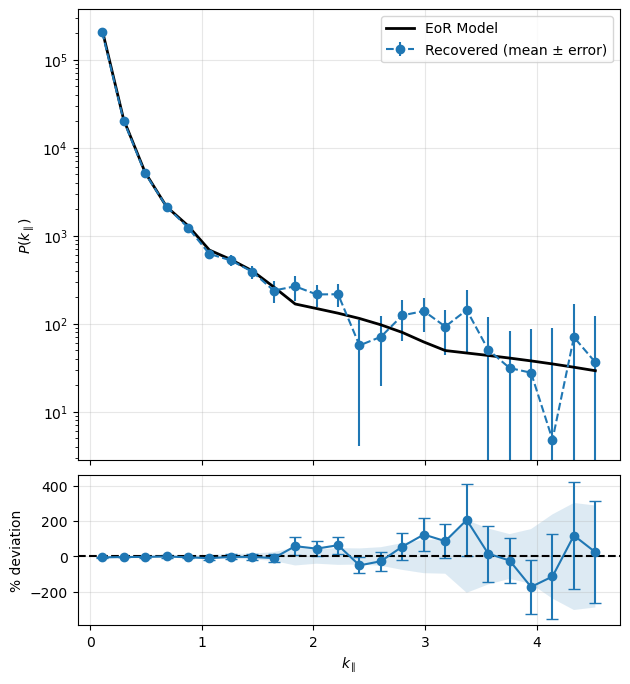

In [7]:
fig, axes = plot_power_with_ratio(k_centers, p_rec_mean, p_rec_err, binned_th,
                                  theory_label='EoR Model')
plt.show()


/home/asif/miniconda3/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1317: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/asif/miniconda3/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1317: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


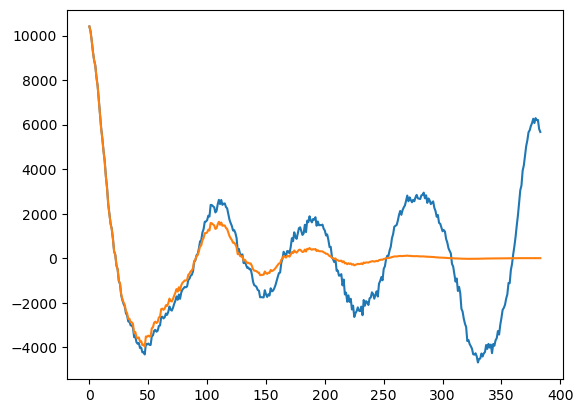

In [8]:
plt.plot(cl)
plt.plot(cl*w)


In [9]:
ml

array([625.+0.j, 501.+0.j, 512.+0.j, 498.+0.j, 505.+0.j, 505.+0.j,
       504.+0.j, 496.+0.j, 500.+0.j, 496.+0.j, 496.+0.j, 501.+0.j,
       494.+0.j, 507.+0.j, 501.+0.j, 497.+0.j, 499.+0.j, 499.+0.j,
       491.+0.j, 496.+0.j, 489.+0.j, 492.+0.j, 488.+0.j, 492.+0.j,
       484.+0.j, 490.+0.j, 494.+0.j, 498.+0.j, 488.+0.j, 487.+0.j,
       491.+0.j, 482.+0.j, 489.+0.j, 492.+0.j, 489.+0.j, 482.+0.j,
       480.+0.j, 485.+0.j, 479.+0.j, 479.+0.j, 485.+0.j, 480.+0.j,
       478.+0.j, 488.+0.j, 476.+0.j, 482.+0.j, 484.+0.j, 476.+0.j,
       473.+0.j, 475.+0.j, 473.+0.j, 470.+0.j, 480.+0.j, 469.+0.j,
       470.+0.j, 469.+0.j, 468.+0.j, 465.+0.j, 463.+0.j, 467.+0.j,
       469.+0.j, 462.+0.j, 461.+0.j, 469.+0.j, 463.+0.j, 469.+0.j,
       457.+0.j, 465.+0.j, 455.+0.j, 465.+0.j, 458.+0.j, 466.+0.j,
       458.+0.j, 462.+0.j, 453.+0.j, 454.+0.j, 454.+0.j, 459.+0.j,
       451.+0.j, 448.+0.j, 453.+0.j, 446.+0.j, 453.+0.j, 450.+0.j,
       451.+0.j, 452.+0.j, 455.+0.j, 449.+0.j, 449.+0.j, 447.+